In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')


In [ ]:
tickers = ["JPM", "PLTR", "V"]
n_assets = len(tickers)
end = dt.datetime.today()
start = end - dt.timedelta(days=365*3)

# Descargar precios de cierre
data = yf.download(tickers, start=start, end=end)["Close"]

In [ ]:
returns = data.pct_change().dropna()
mean_daily = returns.mean()
cov_daily = returns.cov()
mean_annual = mean_daily * 252
cov_annual = cov_daily * 252

n_sim = 10000
rf = 0.04

[*********************100%***********************]  3 of 3 completed


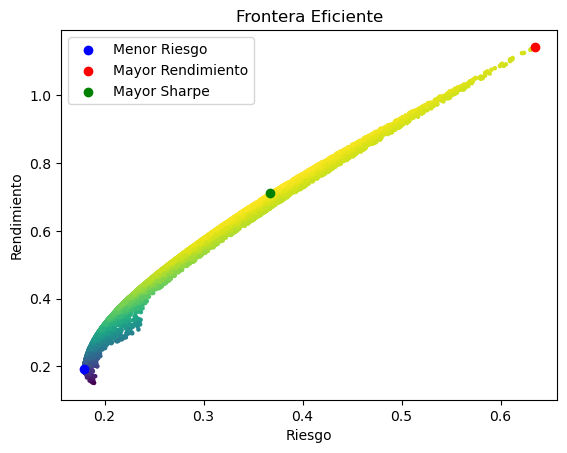

Pesos del Portafolio de Máximo Sharpe:
JPM: 0.5327598549761435
PLTR: 0.4670560702829882
V: 0.0001840747408681897


In [ ]:
port_returns = np.zeros(n_sim)
port_volatility = np.zeros(n_sim)
port_sharpe = np.zeros(n_sim)
all_weights = np.zeros((n_sim, n_assets))
for i in range(n_sim):
    weights = np.random.random(n_assets)
    weights /= np.sum(weights)
    all_weights[i, :] = weights
    ret = np.sum(weights * mean_annual)
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_annual, weights)))
    sharpe = (ret - rf) / vol
    port_returns[i] = ret
    port_volatility[i] = vol
    port_sharpe[i] = sharpe

resultados = pd.DataFrame({
    'Rendimiento': port_returns,
    'Riesgo': port_volatility,
    'Sharpe': port_sharpe
})

min_risk_idx = resultados['Riesgo'].idxmin()
max_ret_idx = resultados['Rendimiento'].idxmax()
max_sharpe_idx = resultados['Sharpe'].idxmax()

min_risk_port = resultados.iloc[min_risk_idx]
max_ret_port = resultados.iloc[max_ret_idx]
max_sharpe_port = resultados.iloc[max_sharpe_idx]

plt.scatter(resultados['Riesgo'], resultados['Rendimiento'], c=resultados['Sharpe'], s=5)
plt.scatter(min_risk_port['Riesgo'], min_risk_port['Rendimiento'], color='blue', label='Menor Riesgo')
plt.scatter(max_ret_port['Riesgo'], max_ret_port['Rendimiento'], color='red', label='Mayor Rendimiento')
plt.scatter(max_sharpe_port['Riesgo'], max_sharpe_port['Rendimiento'], color='green', label='Mayor Sharpe')
plt.title('Frontera Eficiente')
plt.xlabel('Riesgo')
plt.ylabel('Rendimiento')
plt.legend()
plt.show()
opt_weights = all_weights[max_sharpe_idx]
print("Pesos del Portafolio de Máximo Sharpe:")
for ticker, weight in zip(tickers, opt_weights):
    print(f"{ticker}: {weight}")

el portafolio que yo recomendaria seria el portafolio en maximo de sharpe ya que evaluamos dos variables que es la media y la varianza, en los otros casos solo se evalua 1 variable sea el retorno o la varianza. y se hace un problema de optimizacion entre dos variables muy interesante.